<a href="https://colab.research.google.com/github/patinohoyosgisell/Challenge_Telecom_X/blob/main/Challenge_Telecom_XV1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📌 Extracción

In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [230]:
!pip install requests


In [231]:
import requests
import json

In [232]:
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
datos = requests.get(url).json()

In [233]:
#Convirtiendo a DataFrame
df = pd.DataFrame(datos)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# 🔧 Transformación

In [234]:
#normalizando los datos
df = pd.json_normalize(datos)
df.tail()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65
7266,9995-HOTOH,No,Male,0,Yes,Yes,63,No,No phone service,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Electronic check,59.00,3707.6


In [235]:
# Ver nombres de columnas y tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [236]:
#convirtiendo tipo variable object a float64
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

In [237]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [238]:
#nombres de columnas
print(df.columns)

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')


In [239]:
# reiniciar el df para garantizar que los nombres de las columnas guarden bien
df = pd.json_normalize(datos)

# Estandarizando todos los nombres en minúsculas
df.columns = df.columns.str.lower()

In [240]:
df.isnull().values.any()

np.False_

In [241]:
df.isnull().sum()

,0
customerid,0
churn,0
customer.gender,0
customer.seniorcitizen,0
customer.partner,0
customer.dependents,0
customer.tenure,0
phone.phoneservice,0
phone.multiplelines,0
internet.internetservice,0


In [242]:
df['churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [243]:
import numpy as np

df = df.replace(r'^\s*$', np.nan, regex=True)

In [244]:
cols_yes_no = df.columns[df.isin(['Yes','No']).any()]

df[cols_yes_no] = df[cols_yes_no].replace({'Yes':1,'No':0})

df[cols_yes_no] = df[cols_yes_no].fillna(2)

/tmp/ipykernel_139/700231018.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols_yes_no] = df[cols_yes_no].replace({'Yes':1,'No':0})


In [245]:
df.head()

,customerid,churn,customer.gender,customer.seniorcitizen,customer.partner,customer.dependents,customer.tenure,phone.phoneservice,phone.multiplelines,internet.internetservice,...,internet.onlinebackup,internet.deviceprotection,internet.techsupport,internet.streamingtv,internet.streamingmovies,account.contract,account.paperlessbilling,account.paymentmethod,account.charges.monthly,account.charges.total
0,0002-ORFBO,0.0,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.6,593.3
1,0003-MKNFE,0.0,Male,0,0,0,9,1,1,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.4
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,0011-IGKFF,1.0,Male,1,1,0,13,1,0,Fiber optic,...,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,0,Fiber optic,...,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.4


In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7267 non-null   object 
 1   churn                      7267 non-null   float64
 2   customer.gender            7267 non-null   object 
 3   customer.seniorcitizen     7267 non-null   int64  
 4   customer.partner           7267 non-null   int64  
 5   customer.dependents        7267 non-null   int64  
 6   customer.tenure            7267 non-null   int64  
 7   phone.phoneservice         7267 non-null   int64  
 8   phone.multiplelines        7267 non-null   object 
 9   internet.internetservice   7267 non-null   object 
 10  internet.onlinesecurity    7267 non-null   object 
 11  internet.onlinebackup      7267 non-null   object 
 12  internet.deviceprotection  7267 non-null   object 
 13  internet.techsupport       7267 non-null   objec

In [247]:
#convirtiendo tipo variable object a int64
df['churn'] = pd.to_numeric(df['churn'], errors='coerce')
df['account.charges.total'] = pd.to_numeric(df['account.charges.total'], errors='coerce')


In [248]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7267 non-null   object 
 1   churn                      7267 non-null   float64
 2   customer.gender            7267 non-null   object 
 3   customer.seniorcitizen     7267 non-null   int64  
 4   customer.partner           7267 non-null   int64  
 5   customer.dependents        7267 non-null   int64  
 6   customer.tenure            7267 non-null   int64  
 7   phone.phoneservice         7267 non-null   int64  
 8   phone.multiplelines        7267 non-null   object 
 9   internet.internetservice   7267 non-null   object 
 10  internet.onlinesecurity    7267 non-null   object 
 11  internet.onlinebackup      7267 non-null   object 
 12  internet.deviceprotection  7267 non-null   object 
 13  internet.techsupport       7267 non-null   objec

In [249]:
#valores duplicados
df.duplicated().sum()

np.int64(0)

In [250]:
# Traducción de nombres de columnas
traduccion_columnas = {
    "customerid": "id_cliente",
    "churn": "cancelacion",
    "customer.gender": "cliente.genero",
    "customer.seniorcitizen": "cliente.ciudadano_senior",
    "customer.partner": "cliente.pareja",
    "customer.dependents": "cliente.dependientes",
    "customer.tenure": "cliente.antiguedad",
    "phone.phoneservice": "telefono.servicio_telefonico",
    "phone.multiplelines": "telefono.lineas_multiples",
    "internet.internetservice": "internet.servicio_internet",
    "internet.onlinesecurity": "internet.seguridad_en_linea",
    "internet.onlinebackup": "internet.copia_seguridad",
    "internet.deviceprotection": "internet.proteccion_dispositivo",
    "internet.techsupport": "internet.soporte_tecnico",
    "internet.streamingtv": "internet.tv_streaming",
    "internet.streamingmovies": "internet.peliculas_streaming",
    "account.contract": "cuenta.contrato",
    "account.paperlessbilling": "cuenta.facturacion_sin_papel",
    "account.paymentmethod": "cuenta.metodo_pago",
    "account.charges.monthly": "cuenta.cargos_mensuales",
    "account.charges.total": "cuenta.cargos_totales"
}

df = df.rename(columns=traduccion_columnas)

# Traducción de valores
traduccion_valores = {
    "Yes": "Si",
    "No": "No",
    "Female": "Mujer",
    "Male": "Hombre",
    "No phone service": "Sin servicio telefonico",
    "No internet service": "Sin servicio de internet",
    "DSL": "DSL",
    "Fiber optic": "Fibra optica",
    "Month-to-month": "Mes a mes",
    "One year": "Un año",
    "Two year": "Dos años",
    "Electronic check": "Cheque electronico",
    "Mailed check": "Cheque por correo",
    "Credit card (automatic)": "Tarjeta de credito (automatica)",
    "Bank transfer (automatic)": "Transferencia bancaria (automatica)"
}

# Aplicar traducciones a todas las columnas de tipo "object"
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].replace(traduccion_valores)

print("Traducción aplicada:")
print(df.head(3))


Traducción aplicada:
   id_cliente  cancelacion cliente.genero  cliente.ciudadano_senior  \
0  0002-ORFBO          0.0          Mujer                         0   
1  0003-MKNFE          0.0         Hombre                         0   
2  0004-TLHLJ          1.0         Hombre                         0   

   cliente.pareja  cliente.dependientes  cliente.antiguedad  \
0               1                     1                   9   
1               0                     0                   9   
2               0                     0                   4   

   telefono.servicio_telefonico telefono.lineas_multiples  \
0                             1                         0   
1                             1                         1   
2                             1                         0   

  internet.servicio_internet  ... internet.copia_seguridad  \
0                        DSL  ...                        1   
1                        DSL  ...                        0   
2         

In [251]:
print(df.columns)

Index(['id_cliente', 'cancelacion', 'cliente.genero',
       'cliente.ciudadano_senior', 'cliente.pareja', 'cliente.dependientes',
       'cliente.antiguedad', 'telefono.servicio_telefonico',
       'telefono.lineas_multiples', 'internet.servicio_internet',
       'internet.seguridad_en_linea', 'internet.copia_seguridad',
       'internet.proteccion_dispositivo', 'internet.soporte_tecnico',
       'internet.tv_streaming', 'internet.peliculas_streaming',
       'cuenta.contrato', 'cuenta.facturacion_sin_papel', 'cuenta.metodo_pago',
       'cuenta.cargos_mensuales', 'cuenta.cargos_totales'],
      dtype='object')


In [252]:
df['cuentas_diarias'] = (df['cuenta.cargos_mensuales'] / 30).round(1)

Se crea la variable Cuentas_Diarias a partir de la facturación mensual para analizar el gasto promedio diario de los clientes.

In [253]:
df[['cuenta.cargos_mensuales', 'cuentas_diarias']].head()

,cuenta.cargos_mensuales,cuentas_diarias
0,65.6,2.2
1,59.9,2.0
2,73.9,2.5
3,98.0,3.3
4,83.9,2.8


# 📊 Carga y análisis

In [254]:
#Análisis descriptivo
df.describe()

,cancelacion,cliente.ciudadano_senior,cliente.pareja,cliente.dependientes,cliente.antiguedad,telefono.servicio_telefonico,cuenta.facturacion_sin_papel,cuenta.cargos_mensuales,cuenta.cargos_totales,cuentas_diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.318839,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2280.634213,2.158745
std,0.528079,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2268.632997,1.002283
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.600000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,400.225000,1.200000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.300000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3785.300000,3.000000
max,2.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,4.000000


In [255]:
df['cancelacion'].value_counts()

,count
cancelacion,
0.0,5174
1.0,1869
2.0,224


# 📄Informe final

In [256]:
import matplotlib.pyplot as plt

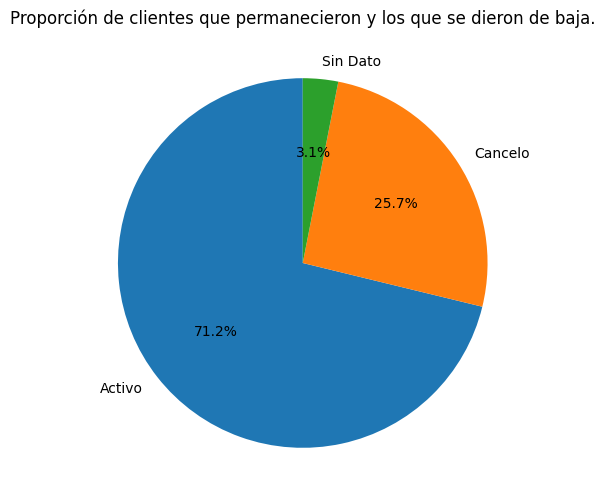

In [259]:
import matplotlib.pyplot as plt

cancelacion_part = df['cancelacion'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    cancelacion_part,
    labels=['Activo','Cancelo', 'Sin Dato'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Proporción de clientes que permanecieron y los que se dieron de baja.')
plt.show()

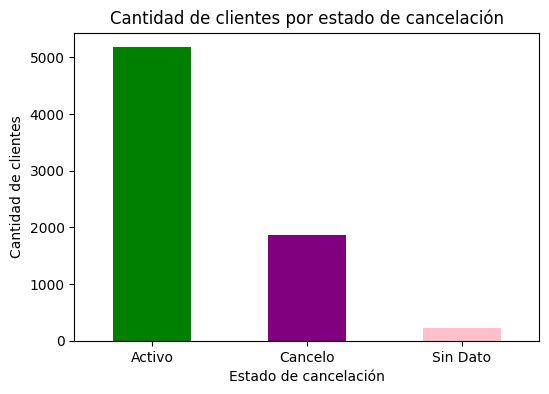

In [265]:
plt.figure(figsize=(6, 4))
cancelacion_part.plot(kind='bar', color=['green', 'purple', 'pink'])
plt.title("Cantidad de clientes por estado de cancelación")
labels=['Activo','Cancelo', 'Sin Dato']
plt.xlabel("Estado de cancelación")
plt.ylabel("Cantidad de clientes")
plt.xticks(ticks=cancelacion_part.index, labels=labels, rotation=0)
plt.show()

# Recuento de evasión por variables categóricas

**Cancelación segun tipo de contrato**

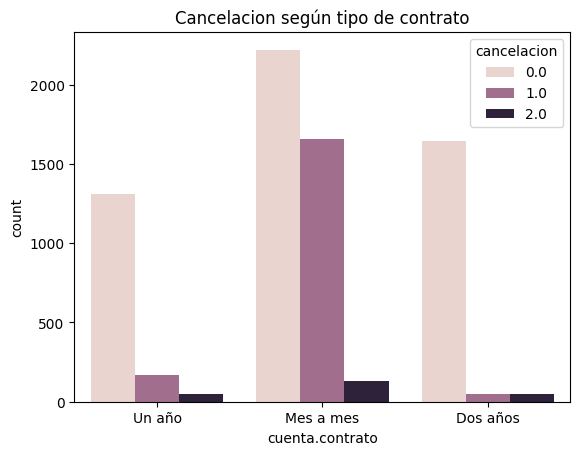

In [266]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='cuenta.contrato', hue='cancelacion')
plt.title('Cancelacion según tipo de contrato')
plt.show()

In [268]:
crosstab_result = pd.crosstab(df['cuenta.contrato'], df['cancelacion'], normalize='index')
crosstab_result.columns = ['Activo', 'Cancelo', 'Sin Dato']
print(crosstab_result)

                   Activo   Cancelo  Sin Dato
cuenta.contrato                              
Dos años         0.944923  0.027539  0.027539
Mes a mes        0.554307  0.413233  0.032459
Un año           0.860434  0.109282  0.030283


**Cancelación según método de pago**

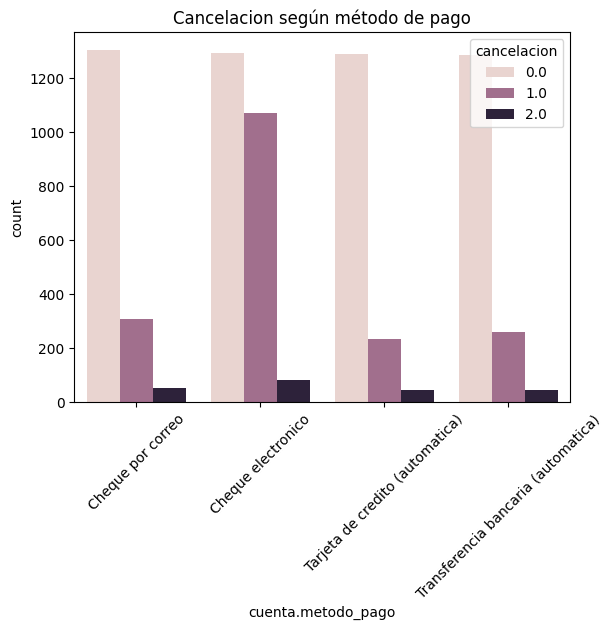

In [271]:
sns.countplot(data=df, x='cuenta.metodo_pago', hue='cancelacion')
plt.title('Cancelacion según método de pago')
plt.xticks(rotation=45)
plt.show()

In [272]:
crosstab_result = pd.crosstab(df['cuenta.metodo_pago'], df['cancelacion'], normalize='index')
crosstab_result.columns = ['Activo', 'Cancelo', 'Sin Dato']
print(crosstab_result)

                                       Activo   Cancelo  Sin Dato
cuenta.metodo_pago                                               
Cheque electronico                   0.529243  0.438037  0.032720
Cheque por correo                    0.783183  0.184985  0.031832
Tarjeta de credito (automatica)      0.822704  0.147959  0.029337
Transferencia bancaria (automatica)  0.809314  0.162366  0.028320


**Cancelación según antiguedad**

In [283]:
tabla_tenure = df.groupby('cancelacion')['cliente.antiguedad'].mean().round(2)
tabla_tenure

,cliente.antiguedad
cancelacion,
0.0,37.57
1.0,17.98
2.0,31.57


In [286]:
description_table = df.groupby('cancelacion')['cliente.antiguedad'].describe()
description_table.index = ['Activo', 'Cancelo', 'Sin Dato']
print(description_table)

           count       mean        std  min   25%   50%   75%   max
Activo    5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Cancelo   1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0
Sin Dato   224.0  31.571429  24.998552  1.0   7.0  29.0  56.0  72.0


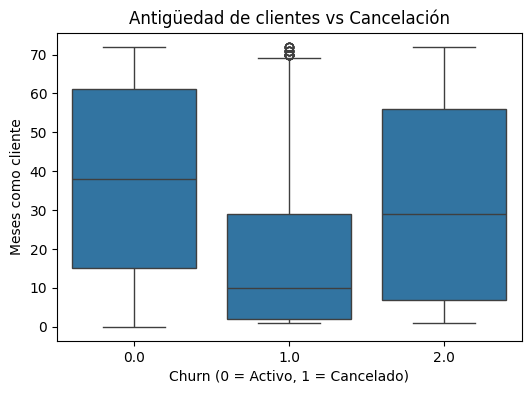

In [287]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x='cancelacion',
    y='cliente.antiguedad'
)

plt.title('Antigüedad de clientes vs Cancelación')
plt.xlabel('Churn (0 = Activo, 1 = Cancelado)')
plt.ylabel('Meses como cliente')

plt.show()

**Cancelación según genero**

In [276]:
tabla_genero = pd.crosstab(df['cliente.genero'], df['cancelacion'])
tabla_genero.columns = ['Activo', 'Cancelo', 'Sin Dato']
tabla_genero

,Activo,Cancelo,Sin Dato
cliente.genero,,,
Hombre,2625,930,120
Mujer,2549,939,104


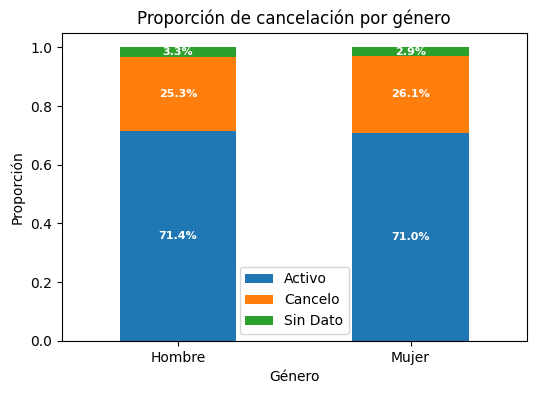

In [281]:
tabla_genero_pct = pd.crosstab(
    df['cliente.genero'],
    df['cancelacion'],
    normalize='index'
)

tabla_genero_pct.columns = ['Activo', 'Cancelo', 'Sin Dato']

ax = tabla_genero_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(6,4)
)

plt.title('Proporción de cancelación por género')
plt.xlabel('Género')
plt.ylabel('Proporción')

# Add data labels
for container in ax.containers:
    for patch in container.patches:
        width = patch.get_width()
        height = patch.get_height()
        x, y = patch.get_xy()
        # Only label non-zero values
        if height > 0.01: # Threshold to avoid labeling very small segments
            ax.text(x + width / 2, y + height / 2, f'{height:.1%}', ha='center', va='center', color='white', fontsize=8, weight='bold')

plt.xticks(rotation=0)
plt.show()

# Conteo de evasión por variables numéricas

In [289]:
df.select_dtypes(include=['int64','float64']).columns

Index(['cancelacion', 'cliente.ciudadano_senior', 'cliente.pareja',
       'cliente.dependientes', 'cliente.antiguedad',
       'telefono.servicio_telefonico', 'cuenta.facturacion_sin_papel',
       'cuenta.cargos_mensuales', 'cuenta.cargos_totales', 'cuentas_diarias'],
      dtype='object')

In [291]:
tabla_numericas = df.groupby('cancelacion')[[
    'cliente.antiguedad',
    'cuenta.cargos_mensuales',
    'cuenta.cargos_totales',
    'cuentas_diarias'
]].mean().round(2)
tabla_numericas.index = ['Activo', 'Cancelo', 'Sin Dato']
tabla_numericas

,cliente.antiguedad,cuenta.cargos_mensuales,cuenta.cargos_totales,cuentas_diarias
Activo,37.57,61.27,2555.34,2.04
Cancelo,17.98,74.44,1531.80,2.48
Sin Dato,31.57,63.41,2196.93,2.11


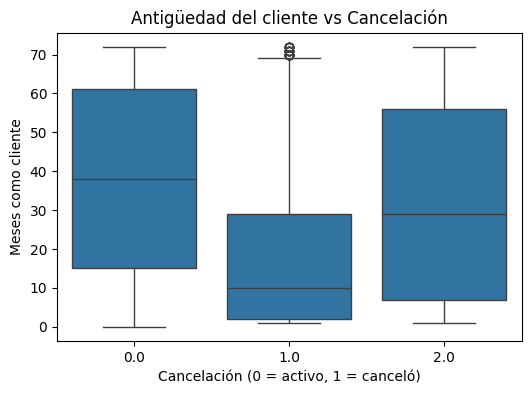

In [292]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x='cancelacion',
    y='cliente.antiguedad'
)

plt.title('Antigüedad del cliente vs Cancelación')
plt.xlabel('Cancelación (0 = activo, 1 = canceló)')
plt.ylabel('Meses como cliente')

plt.show()

Clientes con menor antigüedad cancelan más.

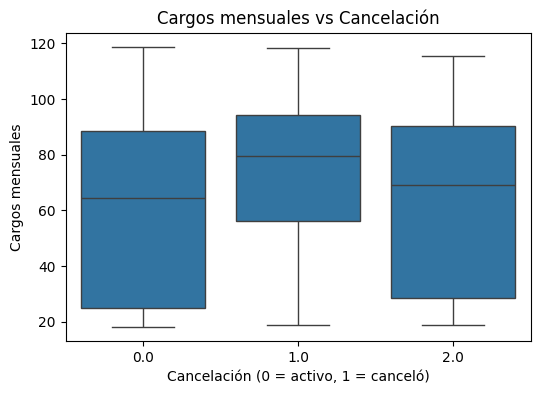

In [294]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x='cancelacion',
    y='cuenta.cargos_mensuales'
)

plt.title('Cargos mensuales vs Cancelación')
plt.xlabel('Cancelación (0 = activo, 1 = canceló)')
plt.ylabel('Cargos mensuales')

plt.show()

Clientes con cargos más altos tienden a cancelar más.

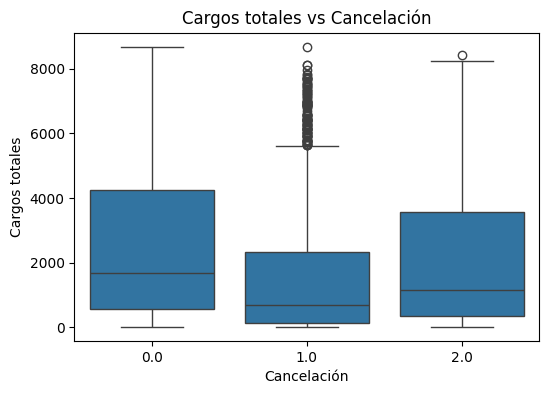

In [295]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x='cancelacion',
    y='cuenta.cargos_totales'
)

plt.title('Cargos totales vs Cancelación')
plt.xlabel('Cancelación')
plt.ylabel('Cargos totales')

plt.show()

Clientes que cancelan suelen tener menor gasto total, porque permanecen menos tiempo.

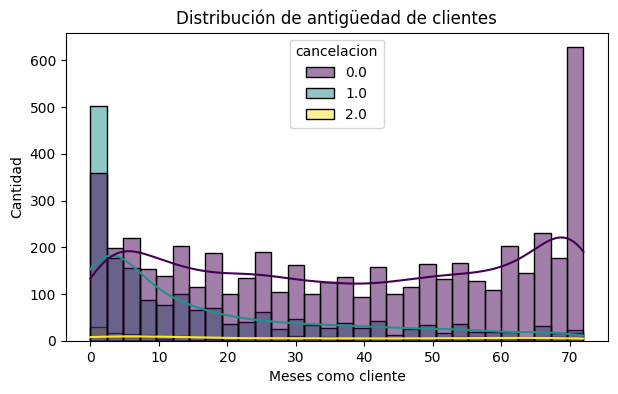

In [297]:
plt.figure(figsize=(7,4))

sns.histplot(
    data=df,
    x='cliente.antiguedad',
    hue='cancelacion',
    bins=30,
    kde=True,
    palette='viridis' # Changed palette to 'viridis' for distinct colors
)

plt.title('Distribución de antigüedad de clientes')
plt.xlabel('Meses como cliente')
plt.ylabel('Cantidad')

plt.show()

In [298]:
corr = df.select_dtypes(include=['int64','float64']).corr()

corr

,cancelacion,cliente.ciudadano_senior,cliente.pareja,cliente.dependientes,cliente.antiguedad,telefono.servicio_telefonico,cuenta.facturacion_sin_papel,cuenta.cargos_mensuales,cuenta.cargos_totales,cuentas_diarias
cancelacion,1.000000,0.126493,-0.115074,-0.129295,-0.288493,0.004765,0.162062,0.152092,-0.165261,0.151097
cliente.ciudadano_senior,0.126493,1.000000,0.022970,-0.212952,0.018187,0.010060,0.157734,0.220388,0.103499,0.220128
cliente.pareja,-0.115074,0.022970,1.000000,0.448900,0.377551,0.018828,-0.011201,0.097122,0.316918,0.097215
cliente.dependientes,-0.129295,-0.212952,0.448900,1.000000,0.159892,-0.003863,-0.111752,-0.115832,0.063960,-0.116037
cliente.antiguedad,-0.288493,0.018187,0.377551,0.159892,1.000000,0.010205,0.007949,0.247982,0.825118,0.247966
telefono.servicio_telefonico,0.004765,0.010060,0.018828,-0.003863,0.010205,1.000000,0.013624,0.246709,0.113791,0.248399
cuenta.facturacion_sin_papel,0.162062,0.157734,-0.011201,-0.111752,0.007949,0.013624,1.000000,0.353714,0.159303,0.353036
cuenta.cargos_mensuales,0.152092,0.220388,0.097122,-0.115832,0.247982,0.246709,0.353714,1.000000,0.652109,0.999560
cuenta.cargos_totales,-0.165261,0.103499,0.316918,0.063960,0.825118,0.113791,0.159303,0.652109,1.000000,0.652310
cuentas_diarias,0.151097,0.220128,0.097215,-0.116037,0.247966,0.248399,0.353036,0.999560,0.652310,1.000000


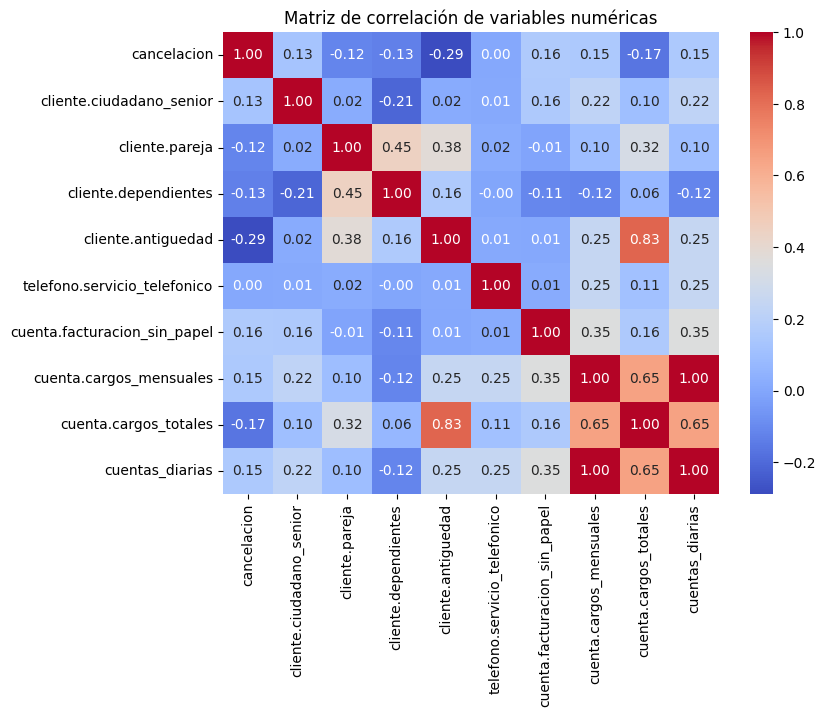

In [299]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title('Matriz de correlación de variables numéricas')

plt.show()

Valores cercanos a:

1 → correlación positiva fuerte

-1 → correlación negativa fuerte

0 → poca relación

**Correlación específica con cancelación**

In [300]:
corr['cancelacion'].sort_values(ascending=False)

,cancelacion
cancelacion,1.000000
cuenta.facturacion_sin_papel,0.162062
cuenta.cargos_mensuales,0.152092
cuentas_diarias,0.151097
cliente.ciudadano_senior,0.126493
telefono.servicio_telefonico,0.004765
cliente.pareja,-0.115074
cliente.dependientes,-0.129295
cuenta.cargos_totales,-0.165261
cliente.antiguedad,-0.288493


antigüedad tiene correlación negativa → clientes antiguos cancelan menos.

cargos mensuales correlación positiva → precios más altos aumentan churn

**Gráfico de dispersión: Cuenta diaria vs Cancelación**

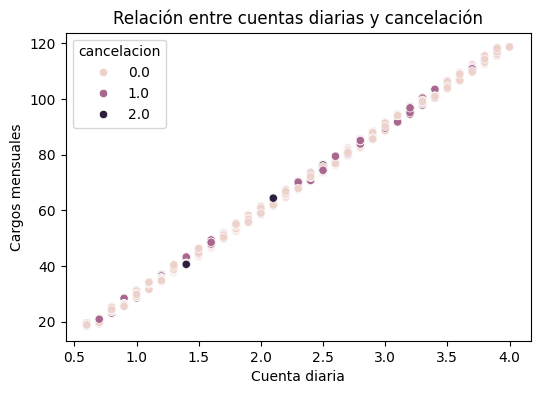

In [301]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x='cuentas_diarias',
    y='cuenta.cargos_mensuales',
    hue='cancelacion'
)

plt.title('Relación entre cuentas diarias y cancelación')
plt.xlabel('Cuenta diaria')
plt.ylabel('Cargos mensuales')

plt.show()

**cantidad de servicios contratados*

In [306]:
servicios = [
'internet.seguridad_en_linea',
'internet.copia_seguridad',
'internet.proteccion_dispositivo',
'internet.soporte_tecnico',
'internet.tv_streaming',
'internet.peliculas_streaming'
]

# Create a temporary DataFrame with the relevant columns and map string values to numeric
temp_df_for_sum = df[servicios].replace({
    'Si': 1,
    'No': 0,
    'Sin servicio de internet': 0 # Map 'Sin servicio de internet' to 0 for counting
})

# Ensure the temporary DataFrame's columns are numeric before summing
temp_df_for_sum = temp_df_for_sum.apply(pd.to_numeric, errors='coerce')

df['cantidad_servicios'] = temp_df_for_sum.sum(axis=1)

/tmp/ipykernel_139/1857660392.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  temp_df_for_sum = df[servicios].replace({


In [307]:
df.groupby('cancelacion')['cantidad_servicios'].mean()

,cantidad_servicios
cancelacion,
0.0,2.135292
1.0,1.768325
2.0,1.919643


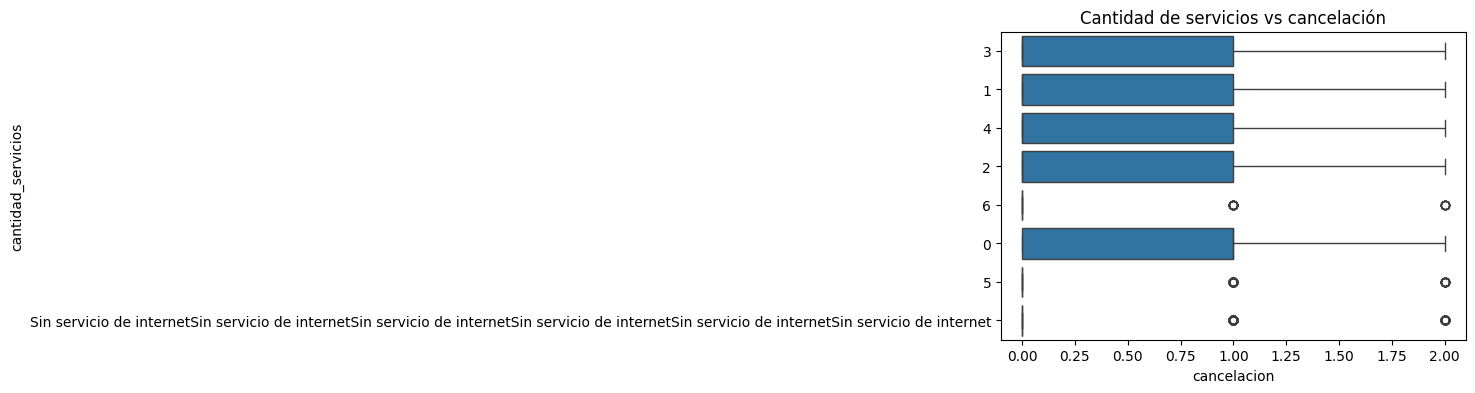

In [305]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x='cancelacion',
    y='cantidad_servicios'
)

plt.title('Cantidad de servicios vs cancelación')

plt.show()